# Dataset Cleaning Process
Following the exact same cleaning steps as in main.ipynb:
1. Drop constant columns (84 -> 72 features)
2. Drop highly correlated (72 -> 57 features)
3. Drop network identifiers (57 -> 52 features)
4. Create 20-feature version from cleaned data

In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import os
import gc
from tqdm import tqdm

# Load datasets
folder_path = os.path.join('..', 'datasets')
filenames = ['metasploitable-2.csv', 'Normal_data.csv', 'OVS.csv']

# Load and combine datasets
dfs = []
for name in filenames:
    file_path = os.path.join(folder_path, name)
    df = pd.read_csv(file_path)
    print(f"Loaded {name} with shape {df.shape}")
    dfs.append(df)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df_raw.shape}")

Loaded metasploitable-2.csv with shape (136743, 84)
Loaded Normal_data.csv with shape (68424, 84)
Loaded Normal_data.csv with shape (68424, 84)
Loaded OVS.csv with shape (138722, 84)

Combined shape: (343889, 84)
Loaded OVS.csv with shape (138722, 84)

Combined shape: (343889, 84)


In [9]:
# Step 1: Drop constant columns (84 -> 72)
constant_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 1]
df_cleaned = df_raw.drop(columns=constant_columns)
print(f"After dropping constant columns: {df_cleaned.shape}")

# Step 2: Drop highly correlated features (72 -> 57)
corr_matrix = df_cleaned.select_dtypes(include=[np.number]).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.99)]
df_cleaned = df_cleaned.drop(columns=to_drop)
print(f"After dropping highly correlated features: {df_cleaned.shape}")

# Step 3: Drop network identifiers (57 -> 52)
network_cols = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Src Port']
df_cleaned = df_cleaned.drop(columns=network_cols, errors='ignore')
print(f"Final shape with 52 features: {df_cleaned.shape}")

# Save 52-feature dataset
os.makedirs('checkpoints/clean', exist_ok=True)
df_cleaned.to_csv('checkpoints/clean/cleaned_52.csv', index=False)
print("\nSaved 52-feature cleaned dataset")

After dropping constant columns: (343889, 72)
After dropping highly correlated features: (343889, 57)
Final shape with 52 features: (343889, 52)
After dropping highly correlated features: (343889, 57)
Final shape with 52 features: (343889, 52)

Saved 52-feature cleaned dataset

Saved 52-feature cleaned dataset


In [11]:
# Check actual column names
print("\nActual columns in cleaned dataset:")
print(sorted(df_cleaned.columns.tolist()))


Actual columns in cleaned dataset:
['ACK Flag Cnt', 'Active Max', 'Active Mean', 'Active Min', 'Active Std', 'Bwd IAT Mean', 'Bwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Tot', 'Bwd PSH Flags', 'Bwd Pkt Len Max', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Min', 'Bwd Pkt Len Std', 'Bwd URG Flags', 'Down/Up Ratio', 'Dst Port', 'FIN Flag Cnt', 'Flow Byts/s', 'Flow Duration', 'Flow IAT Max', 'Flow IAT Mean', 'Flow IAT Min', 'Flow IAT Std', 'Flow Pkts/s', 'Fwd Act Data Pkts', 'Fwd Header Len', 'Fwd IAT Max', 'Fwd IAT Mean', 'Fwd IAT Min', 'Fwd IAT Std', 'Fwd IAT Tot', 'Fwd Pkt Len Max', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Min', 'Fwd Pkt Len Std', 'Fwd Pkts/s', 'Idle Std', 'Init Bwd Win Byts', 'Label', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Min', 'Pkt Len Std', 'Pkt Len Var', 'Protocol', 'RST Flag Cnt', 'SYN Flag Cnt', 'Tot Bwd Pkts', 'Tot Fwd Pkts', 'TotLen Bwd Pkts', 'TotLen Fwd Pkts']


In [12]:
# Create 20-feature version using exact feature list
features_20 = [
    'Init Bwd Win Byts', 'Dst Port', 'Flow Duration', 'Protocol', 'Flow IAT Min',
    'Flow Pkts/s', 'Fwd Pkts/s', 'Flow IAT Max', 'Fwd IAT Max', 'Fwd Header Len',
    'Pkt Len Mean', 'Tot Fwd Pkts', 'Bwd IAT Mean', 'Fwd IAT Tot', 'Bwd Pkt Len Max',
    'Flow IAT Std', 'Bwd Pkt Len Min', 'Bwd IAT Min', 'Pkt Len Max', 'Fwd IAT Mean'
]

# Column name mapping (using actual column names from dataset)
feature_mapping = {
    'Init Bwd Win Byts': 'Init Bwd Win Byts',
    'Dst Port': 'Dst Port',
    'Flow Duration': 'Flow Duration',
    'Protocol': 'Protocol',
    'Flow IAT Min': 'Flow IAT Min',
    'Flow Pkts/s': 'Flow Pkts/s',
    'Fwd Pkts/s': 'Fwd Pkts/s',
    'Flow IAT Max': 'Flow IAT Max',
    'Fwd IAT Max': 'Fwd IAT Max',
    'Fwd Header Len': 'Fwd Header Len',
    'Pkt Len Mean': 'Pkt Len Mean',
    'Tot Fwd Pkts': 'Tot Fwd Pkts',
    'Bwd IAT Mean': 'Bwd IAT Mean',
    'Fwd IAT Tot': 'Fwd IAT Tot',
    'Bwd Pkt Len Max': 'Bwd Pkt Len Max',
    'Flow IAT Std': 'Flow IAT Std',
    'Bwd Pkt Len Min': 'Bwd Pkt Len Min',
    'Bwd IAT Min': 'Bwd IAT Min',
    'Pkt Len Max': 'Pkt Len Max',
    'Fwd IAT Mean': 'Fwd IAT Mean'
}

# Create 20-feature dataset
df_20 = df_cleaned[[feature_mapping[f] for f in features_20] + ['Label']]
df_20.to_csv('checkpoints/clean/cleaned_20.csv', index=False)
print(f"\n20-feature dataset shape: {df_20.shape}")

# Memory cleanup
del df_raw, df_cleaned, df_20
gc.collect()


20-feature dataset shape: (343889, 21)


14588

# CTGAN Training and Synthetic Data Generation
Training CTGAN models for both 52-feature and 20-feature datasets

In [ ]:
# Import required libraries for CTGAN
from ctgan import CTGAN
import pandas as pd
import numpy as np
import os
import gc
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

# Create output directories
os.makedirs('checkpoints/ctgan', exist_ok=True)

def calculate_target_samples(data, balance_strategy='moderate'):
    """
    Calculate target sample sizes for each class based on the balance strategy
    
    Args:
        data: DataFrame containing the data
        balance_strategy: 'aggressive' (all classes equal), 
                        'moderate' (reduce majority, increase minority), 
                        'conservative' (only increase minority)
    Returns:
        Dictionary of label to target sample size
    """
    label_counts = data['Label'].value_counts()
    median_count = label_counts.median()
    max_count = label_counts.max()
    
    target_samples = {}
    
    if balance_strategy == 'aggressive':
        # Make all classes equal to median size
        target_size = int(median_count)
        target_samples = {label: target_size for label in label_counts.index}
        
    elif balance_strategy == 'moderate':
        # Reduce majority classes to 75% of original, increase minority to 50% of that
        majority_target = int(max_count * 0.75)
        minority_target = int(majority_target * 0.5)
        
        for label in label_counts.index:
            if label_counts[label] > majority_target:
                target_samples[label] = majority_target
            elif label_counts[label] < minority_target:
                target_samples[label] = minority_target
            else:
                target_samples[label] = label_counts[label]
                
    else:  # conservative
        # Only increase minority classes to 25% of majority class
        minority_target = int(max_count * 0.25)
        
        for label in label_counts.index:
            if label_counts[label] < minority_target:
                target_samples[label] = minority_target
            else:
                target_samples[label] = label_counts[label]
    
    return target_samples

def train_and_generate_ctgan(data, feature_count, subset_label=None, target_size=None, epochs=300):
    """
    Train CTGAN model and generate synthetic data
    
    Args:
        data: DataFrame containing the data
        feature_count: Number of features (52 or 20)
        subset_label: Optional label value to generate data for
        target_size: Target number of samples for the class
        epochs: Number of training epochs
    """
    # Filter data if subset_label is provided
    if subset_label is not None:
        data = data[data['Label'] == subset_label].copy()
        
    if len(data) == 0:
        print(f"No samples found for label {subset_label}")
        return None
    
    # Initialize CTGAN with optimized parameters
    ctgan = CTGAN(
        epochs=epochs,
        batch_size=500,
        generator_dim=(256, 256),
        discriminator_dim=(256, 256),
        generator_lr=2e-4,
        discriminator_lr=2e-4,
        verbose=True
    )
    
    print(f"\nTraining CTGAN for {feature_count}-feature dataset...")
    if subset_label is not None:
        print(f"Generating data for Label {subset_label} (original samples: {len(data)})")
    
    # Scale numerical columns to [0, 1] range
    columns = data.columns.tolist()
    categorical_columns = ['Protocol', 'Label'] if 'Protocol' in columns else ['Label']
    numerical_columns = [col for col in columns if col not in categorical_columns]
    
    scaler = MinMaxScaler()
    data_scaled = data.copy()
    data_scaled[numerical_columns] = scaler.fit_transform(data[numerical_columns])
    
    # Fit the model
    try:
        ctgan.fit(data_scaled, discrete_columns=categorical_columns)
        
        # Calculate number of samples to generate
        if target_size is not None and subset_label is not None:
            sample_size = target_size - len(data)
            if sample_size <= 0:
                print(f"Undersampling {subset_label} from {len(data)} to {target_size} samples")
                return data.sample(n=target_size, random_state=42)
        else:
            sample_size = len(data)
            
        print(f"\nGenerating {sample_size} synthetic samples...")
        synthetic_data = ctgan.sample(sample_size)
        
        # Inverse transform the scaled features
        synthetic_data_unscaled = synthetic_data.copy()
        synthetic_data_unscaled[numerical_columns] = scaler.inverse_transform(synthetic_data[numerical_columns])
        
        # If generating for specific label, ensure label column matches
        if subset_label is not None:
            synthetic_data_unscaled['Label'] = subset_label
        
        # Combine original and synthetic data if needed
        if sample_size > 0:
            final_data = pd.concat([data, synthetic_data_unscaled], ignore_index=True)
        else:
            final_data = data.sample(n=target_size, random_state=42)
        
        # Save the model
        model_path = f'checkpoints/ctgan/ctgan_{feature_count}'
        model_path += f'_label_{subset_label}' if subset_label is not None else ''
        model_path += '.pkl'
        
        ctgan.save(model_path)
        print(f"Saved CTGAN model to: {model_path}")
        
        return final_data
    
    except Exception as e:
        print(f"Error training CTGAN: {str(e)}")
        return None

# Load the cleaned datasets
df_52 = pd.read_csv('checkpoints/clean/cleaned_52.csv')
df_20 = pd.read_csv('checkpoints/clean/cleaned_20.csv')

print("Loaded datasets:")
print(f"52-feature dataset shape: {df_52.shape}")
print(f"20-feature dataset shape: {df_20.shape}")

# Print original label distribution
print("\nOriginal label distribution:")
label_counts_52 = df_52['Label'].value_counts()
print("52-feature dataset:")
print(label_counts_52.sort_values())

# Calculate target sizes for balanced dataset
target_samples_52 = calculate_target_samples(df_52, balance_strategy='moderate')
target_samples_20 = calculate_target_samples(df_20, balance_strategy='moderate')

print("\nTarget samples per class (52-feature dataset):")
for label, target in sorted(target_samples_52.items()):
    print(f"{label}: {target}")

# Process all classes for both datasets
balanced_data_52 = []
balanced_data_20 = []

# Process 52-feature dataset
print("\nProcessing 52-feature dataset...")
for label in df_52['Label'].unique():
    print(f"\nProcessing label {label}...")
    balanced = train_and_generate_ctgan(df_52, 52, 
                                      subset_label=label,
                                      target_size=target_samples_52[label])
    if balanced is not None:
        balanced_data_52.append(balanced)
    gc.collect()

# Process 20-feature dataset
print("\nProcessing 20-feature dataset...")
for label in df_20['Label'].unique():
    print(f"\nProcessing label {label}...")
    balanced = train_and_generate_ctgan(df_20, 20, 
                                      subset_label=label,
                                      target_size=target_samples_20[label])
    if balanced is not None:
        balanced_data_20.append(balanced)
    gc.collect()

# Combine balanced datasets
if balanced_data_52:
    balanced_52 = pd.concat(balanced_data_52, ignore_index=True)
    balanced_52.to_csv('checkpoints/ctgan/balanced_52.csv', index=False)
    print("\n52-feature balanced data shape:", balanced_52.shape)
    print("\n52-feature balanced data distribution:")
    print(balanced_52['Label'].value_counts().sort_index())

if balanced_data_20:
    balanced_20 = pd.concat(balanced_data_20, ignore_index=True)
    balanced_20.to_csv('checkpoints/ctgan/balanced_20.csv', index=False)
    print("\n20-feature balanced data shape:", balanced_20.shape)
    print("\n20-feature balanced data distribution:")
    print(balanced_20['Label'].value_counts().sort_index())

Loaded datasets:
52-feature dataset shape: (343889, 52)
20-feature dataset shape: (343889, 21)

Label distribution:
Label
U2R              17
BOTNET          164
Web-Attack      192
BFA            1405
DDoS          48413
DoS           53616
Normal        68424
DDoS          73529
Probe         98129
Name: count, dtype: int64

Processing 52-feature dataset...

Generating synthetic data for label BFA...

Training CTGAN for 52-feature dataset...
Generating data for Label BFA (samples: 1405)


Gen. (0.00) | Discrim. (0.00):   0%|          | 0/300 [00:00<?, ?it/s]c:\Users\yuheng\Documents\fyp\backend\fypenv\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
c:\Users\yuheng\Documents\fyp\backend\fypenv\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Gen. (-0.43) | Discrim. (-0.54): 100%|██████████| 300/300 [01:


Generating 1405 synthetic samples...
Saved CTGAN model to: checkpoints/ctgan/ctgan_52_label_BFA.pkl
Saved CTGAN model to: checkpoints/ctgan/ctgan_52_label_BFA.pkl

Generating synthetic data for label BOTNET...

Training CTGAN for 52-feature dataset...
Generating data for Label BOTNET (samples: 164)

Generating synthetic data for label BOTNET...

Training CTGAN for 52-feature dataset...
Generating data for Label BOTNET (samples: 164)


Gen. (-2.44) | Discrim. (-3.61): 100%|██████████| 300/300 [00:21<00:00, 14.25it/s]




Generating 164 synthetic samples...
Saved CTGAN model to: checkpoints/ctgan/ctgan_52_label_BOTNET.pkl

Generating synthetic data for label U2R...

Training CTGAN for 52-feature dataset...
Generating data for Label U2R (samples: 17)

Generating synthetic data for label U2R...

Training CTGAN for 52-feature dataset...
Generating data for Label U2R (samples: 17)


...


Generating 164 synthetic samples...
Saved CTGAN model to: checkpoints/ctgan/ctgan_20_label_BOTNET.pkl

Generating synthetic data for label U2R...

Training CTGAN for 20-feature dataset...
Generating data for Label U2R (samples: 17)

Generating synthetic data for label U2R...

Training CTGAN for 20-feature dataset...
Generating data for Label U2R (samples: 17)


Gen. (-0.10) | Discrim. (-0.21): 100%|██████████| 300/300 [00:21<00:00, 13.91it/s]




Generating 17 synthetic samples...
Saved CTGAN model to: checkpoints/ctgan/ctgan_20_label_U2R.pkl

Generating synthetic data for label Web-Attack...

Training CTGAN for 20-feature dataset...
Generating data for Label Web-Attack (samples: 192)

Generating synthetic data for label Web-Attack...

Training CTGAN for 20-feature dataset...
Generating data for Label Web-Attack (samples: 192)


Gen. (-0.58) | Discrim. (-0.34): 100%|██████████| 300/300 [00:21<00:00, 14.09it/s]




Generating 192 synthetic samples...
Saved CTGAN model to: checkpoints/ctgan/ctgan_20_label_Web-Attack.pkl

52-feature synthetic data shape: (1778, 52)

52-feature synthetic data distribution:
Label
BFA           1405
BOTNET         164
U2R             17
Web-Attack     192
Name: count, dtype: int64

20-feature synthetic data shape: (1778, 21)

20-feature synthetic data distribution:
Label
BFA           1405
BOTNET         164
U2R             17
Web-Attack     192
Name: count, dtype: int64

52-feature synthetic data shape: (1778, 52)

52-feature synthetic data distribution:
Label
BFA           1405
BOTNET         164
U2R             17
Web-Attack     192
Name: count, dtype: int64

20-feature synthetic data shape: (1778, 21)

20-feature synthetic data distribution:
Label
BFA           1405
BOTNET         164
U2R             17
Web-Attack     192
Name: count, dtype: int64


## Visualizing Data Distribution

Let's analyze the distribution of samples before and after synthetic data generation to ensure our CTGAN model is producing balanced and representative data.

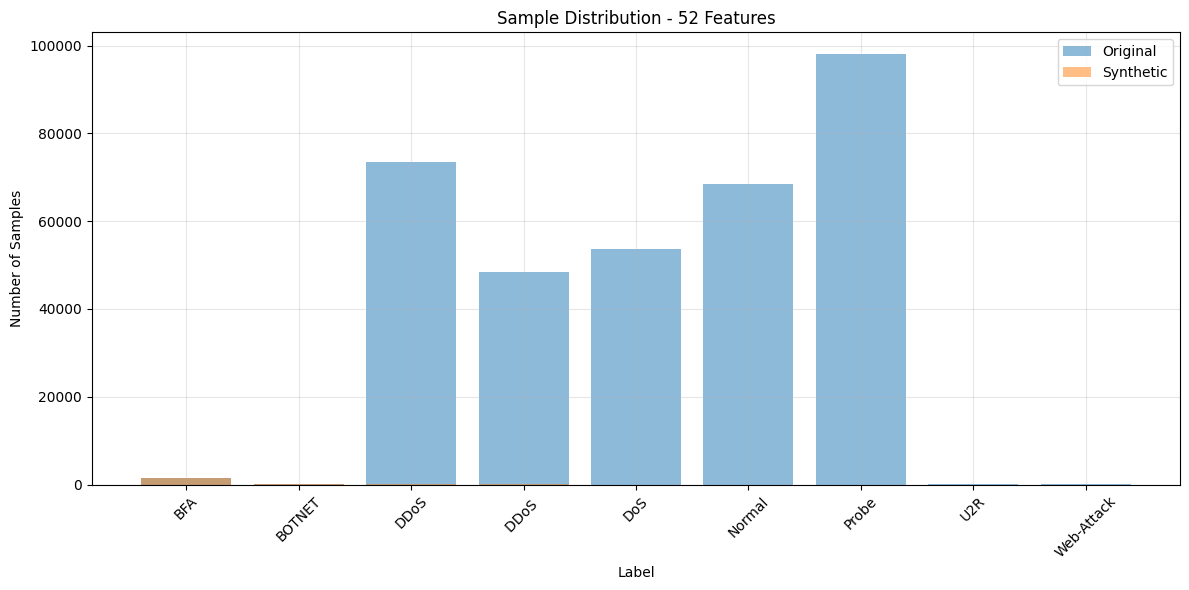

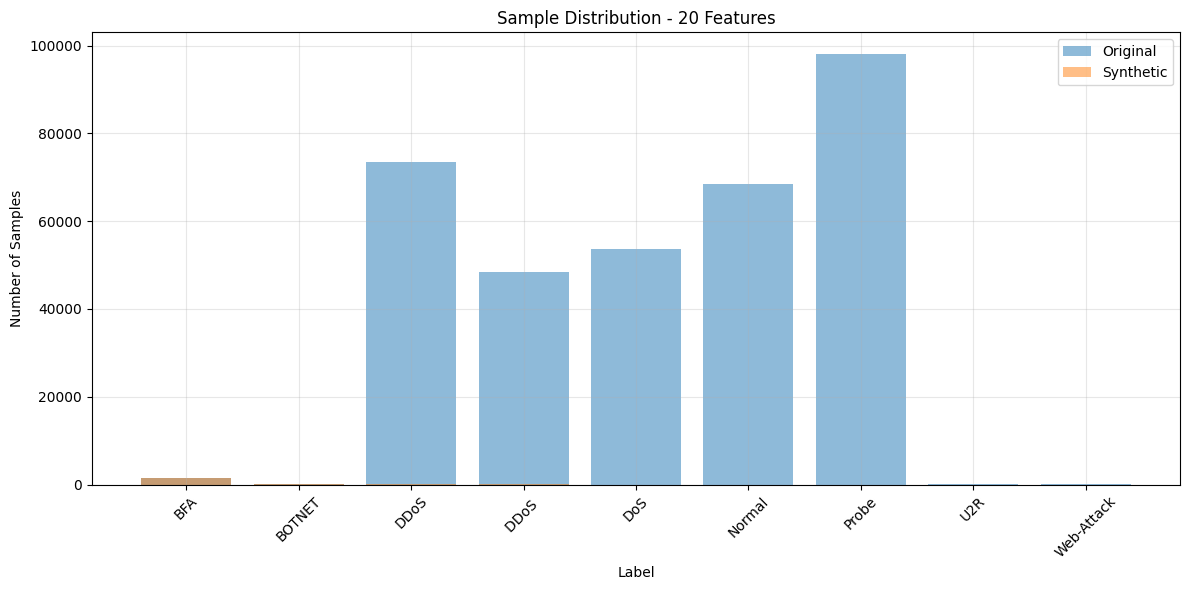

In [ ]:
# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

def plot_sample_distribution(original_data, balanced_data=None, title="Sample Distribution"):
    """
    Plot the distribution of samples across different labels
    
    Args:
        original_data: Original DataFrame
        balanced_data: Optional balanced DataFrame
        title: Plot title
    """
    plt.figure(figsize=(15, 6))
    
    # Get all unique labels
    all_labels = sorted(set(original_data['Label'].unique()) | 
                       (set(balanced_data['Label'].unique()) if balanced_data is not None else set()))
    
    # Calculate counts
    original_counts = original_data['Label'].value_counts()
    balanced_counts = balanced_data['Label'].value_counts() if balanced_data is not None else None
    
    # Set up bar positions
    x = np.arange(len(all_labels))
    width = 0.35
    
    # Plot original data
    plt.bar(x - width/2, [original_counts.get(label, 0) for label in all_labels], 
            width, label='Original', color='skyblue', alpha=0.7)
    
    # Plot balanced data if provided
    if balanced_data is not None:
        plt.bar(x + width/2, [balanced_counts.get(label, 0) for label in all_labels], 
                width, label='Balanced', color='lightgreen', alpha=0.7)
    
    plt.title(title, fontsize=12, pad=20)
    plt.xlabel('Label', fontsize=10)
    plt.ylabel('Number of Samples', fontsize=10)
    plt.xticks(x, all_labels, rotation=45, ha='right')
    plt.legend(fontsize=10)
    
    # Add value labels on top of bars
    def add_value_labels(positions, counts):
        for pos, count in zip(positions, counts):
            plt.text(pos, count, str(count), ha='center', va='bottom')
    
    add_value_labels(x - width/2, [original_counts.get(label, 0) for label in all_labels])
    if balanced_data is not None:
        add_value_labels(x + width/2, [balanced_counts.get(label, 0) for label in all_labels])
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
# Plot distribution for 52-feature dataset
plot_sample_distribution(df_52, balanced_52 if 'balanced_52' in locals() else None, 
                        "Sample Distribution - 52 Features")
plt.show()

# Plot distribution for 20-feature dataset
plot_sample_distribution(df_20, balanced_20 if 'balanced_20' in locals() else None, 
                        "Sample Distribution - 20 Features")
plt.show()

## Feature Distribution Analysis

Now let's analyze the distribution of key features in both original and synthetic data to ensure our CTGAN model is generating realistic samples.

Analyzing 52-feature dataset distributions...


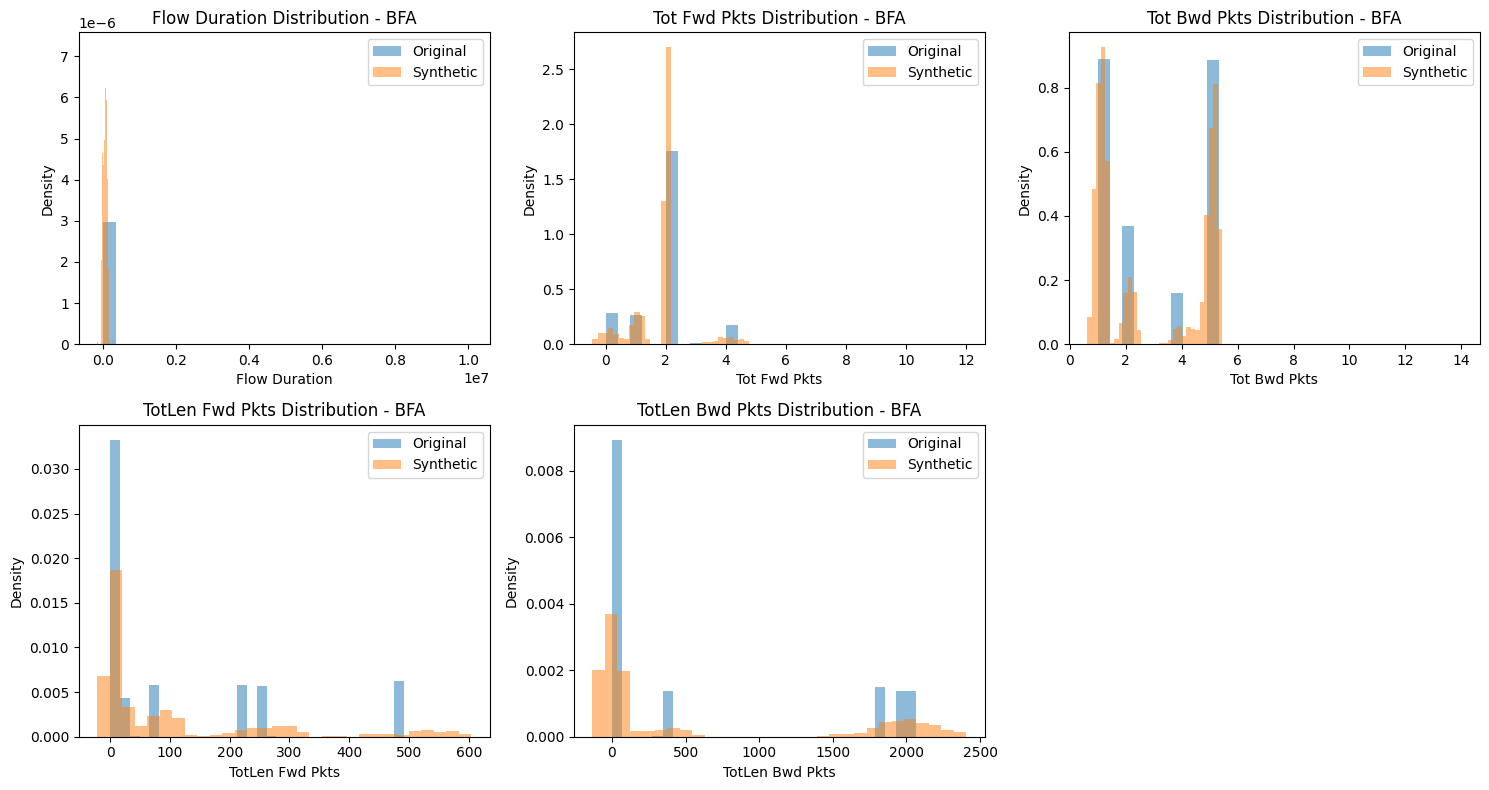

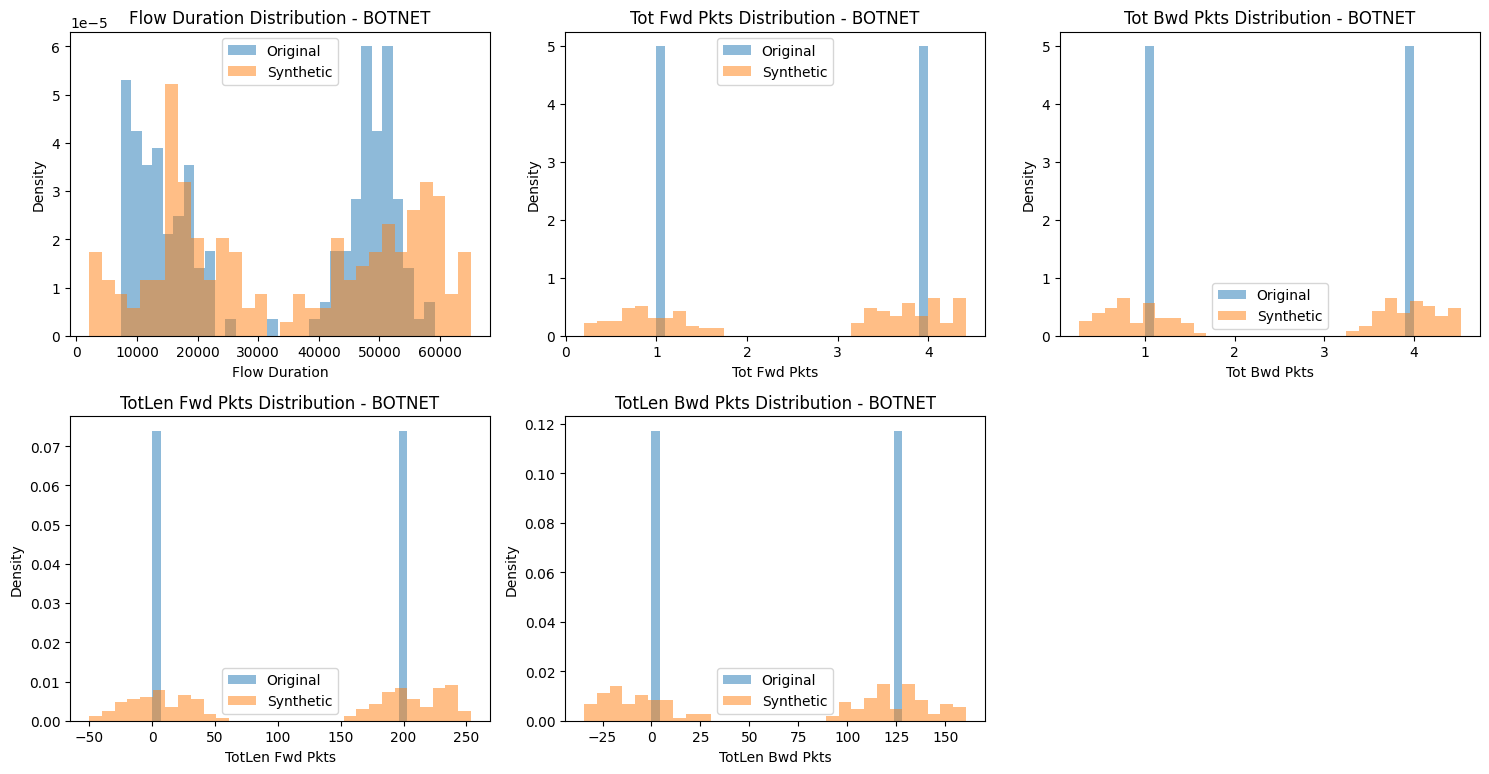

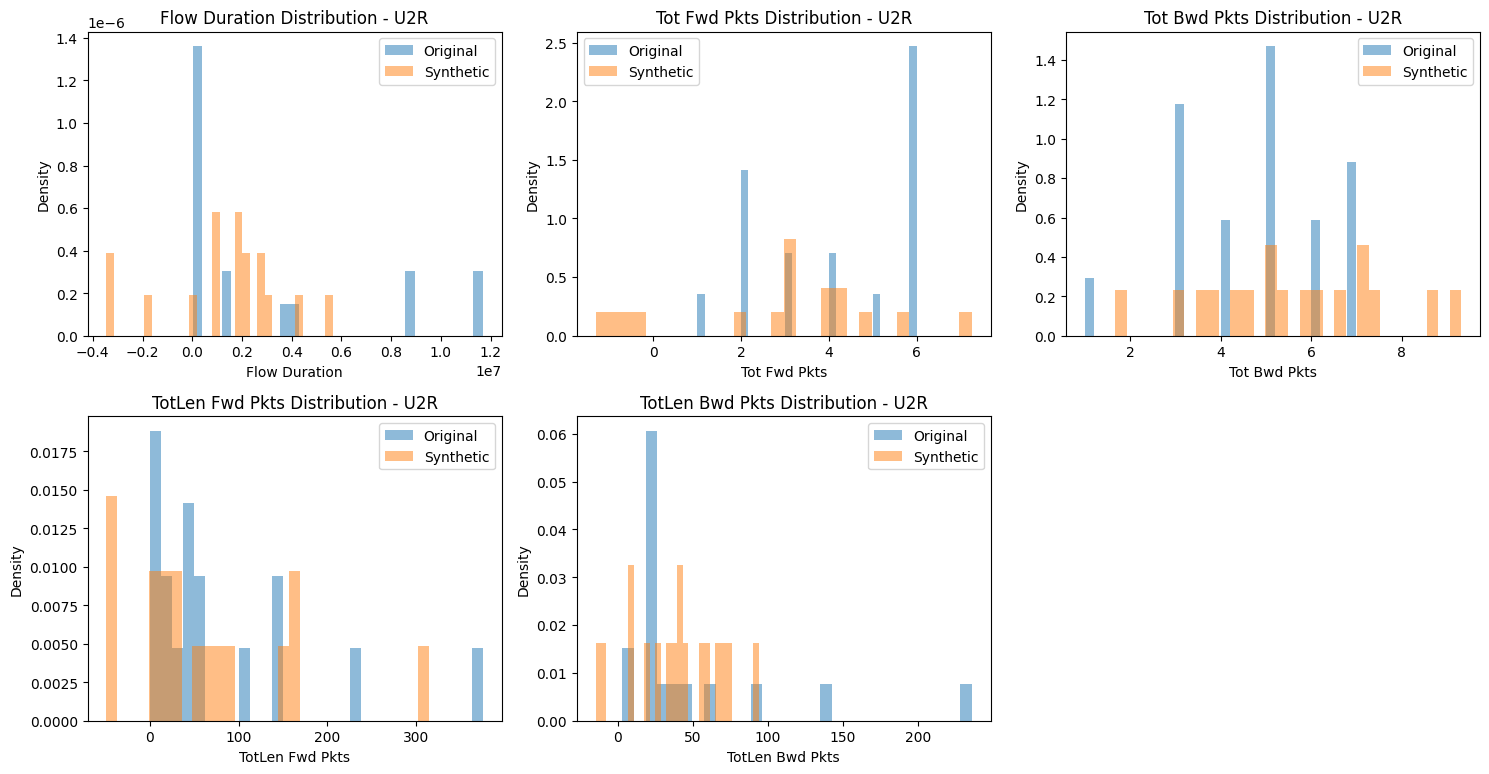

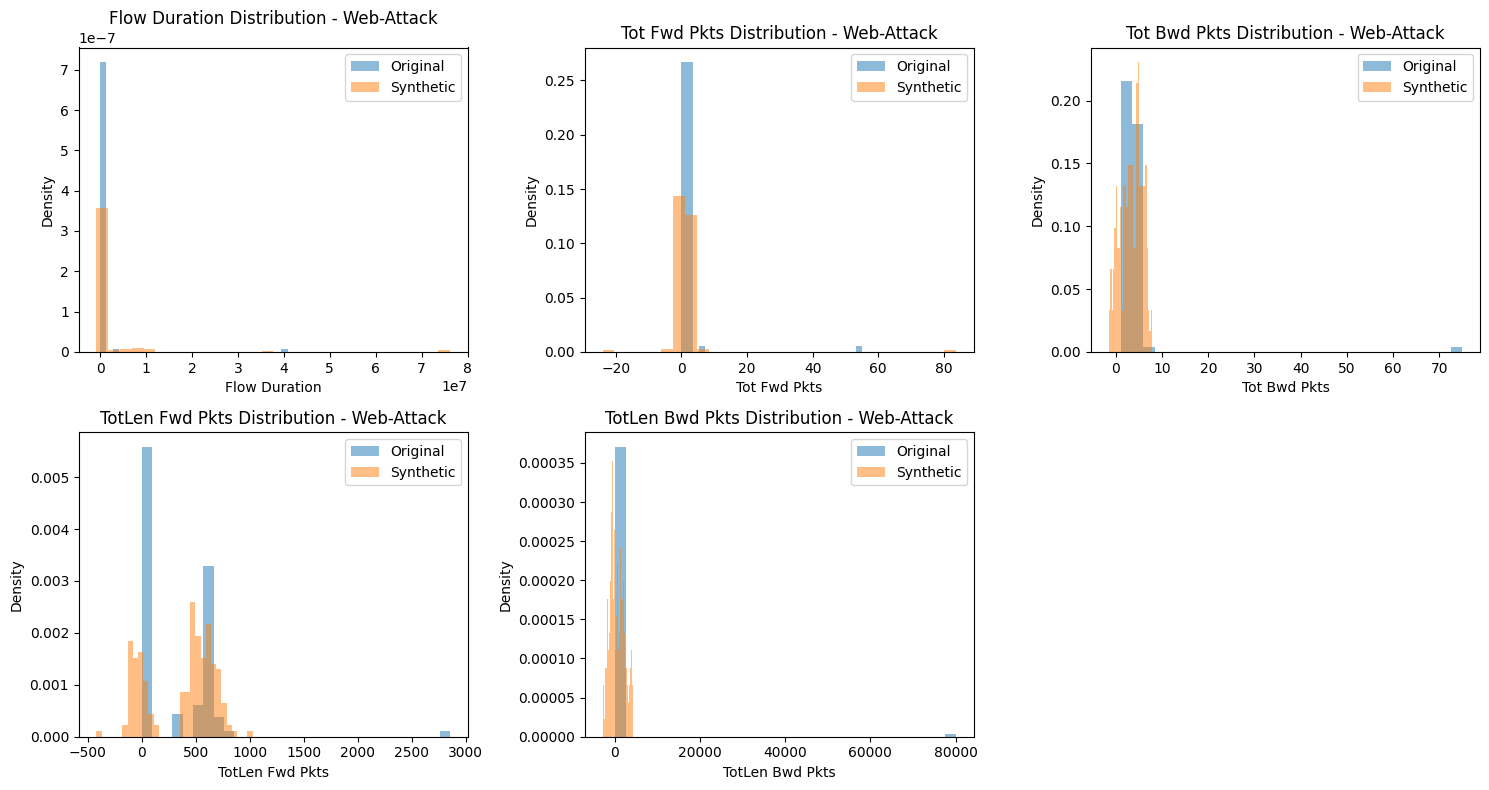


Analyzing 20-feature dataset distributions...


KeyError: 'Tot Bwd Pkts'

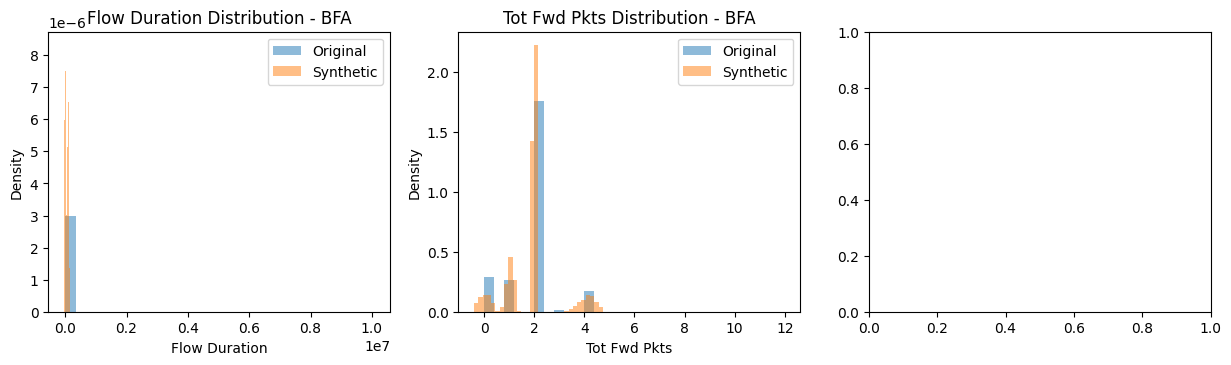

In [22]:
def plot_feature_distributions(original_data, synthetic_data, features, label_value):
    """
    Plot distribution of selected features for original vs synthetic data for a specific label
    
    Args:
        original_data: Original DataFrame
        synthetic_data: Synthetic DataFrame
        features: List of feature names to plot
        label_value: Label value to analyze
    """
    original_subset = original_data[original_data['Label'] == label_value]
    synthetic_subset = synthetic_data[synthetic_data['Label'] == label_value]
    
    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols
    
    plt.figure(figsize=(15, 4*n_rows))
    
    for i, feature in enumerate(features, 1):
        plt.subplot(n_rows, n_cols, i)
        
        # Plot histograms
        plt.hist(original_subset[feature], bins=30, alpha=0.5, label='Original', density=True)
        plt.hist(synthetic_subset[feature], bins=30, alpha=0.5, label='Synthetic', density=True)
        
        plt.title(f'{feature} Distribution - {label_value}')
        plt.xlabel(feature)
        plt.ylabel('Density')
        plt.legend()
        
    plt.tight_layout()
    plt.show()

# Select important features to analyze
features_52 = ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts']
features_20 = ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts']

# Analyze distribution for each minority class
minority_labels = ['BFA', 'BOTNET', 'U2R', 'Web-Attack']

if 'synthetic_52' in locals():
    print("Analyzing 52-feature dataset distributions...")
    for label in minority_labels:
        plot_feature_distributions(df_52, synthetic_52, features_52, label)

if 'synthetic_20' in locals():
    print("\nAnalyzing 20-feature dataset distributions...")
    for label in minority_labels:
        plot_feature_distributions(df_20, synthetic_20, features_20, label)

## Summary Statistics

Finally, let's compare summary statistics between original and synthetic data to ensure the synthetic samples maintain similar statistical properties.

In [23]:
def compare_statistics(original_data, synthetic_data, label_value, features):
    """
    Compare summary statistics between original and synthetic data for a specific label
    
    Args:
        original_data: Original DataFrame
        synthetic_data: Synthetic DataFrame
        label_value: Label value to analyze
        features: List of features to compare
    """
    original_subset = original_data[original_data['Label'] == label_value][features]
    synthetic_subset = synthetic_data[synthetic_data['Label'] == label_value][features]
    
    # Calculate summary statistics
    orig_stats = original_subset.describe()
    syn_stats = synthetic_subset.describe()
    
    # Calculate percentage differences
    diff = ((syn_stats - orig_stats) / orig_stats * 100).round(2)
    
    # Create comparison DataFrame
    comparison = pd.DataFrame({
        'Original': orig_stats.round(2),
        'Synthetic': syn_stats.round(2),
        'Diff (%)': diff
    })
    
    print(f"\nSummary Statistics Comparison for {label_value}:")
    print("=" * 80)
    print(comparison)
    print("\n")

# Compare statistics for each minority class
if 'synthetic_52' in locals():
    print("52-Feature Dataset Statistics:")
    print("=" * 80)
    for label in minority_labels:
        compare_statistics(df_52, synthetic_52, label, features_52)

if 'synthetic_20' in locals():
    print("\n20-Feature Dataset Statistics:")
    print("=" * 80)
    for label in minority_labels:
        compare_statistics(df_20, synthetic_20, label, features_20)

52-Feature Dataset Statistics:


ValueError: If using all scalar values, you must pass an index

# Analyzing Data Distribution and Sample Size Strategy

Let's visualize:
1. Current class distribution (original vs synthetic)
2. Target balanced distribution
3. Sample size analysis for minority classes

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get class distribution for original and synthetic data
def plot_distribution_comparison(original_df, synthetic_df=None, target_size=None):
    # Get original distribution
    orig_dist = original_df['Label'].value_counts().sort_index()
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Original vs Synthetic
    ax1.bar(range(len(orig_dist)), orig_dist.values, alpha=0.5, label='Original', color='blue')
    if synthetic_df is not None:
        synth_dist = synthetic_df['Label'].value_counts().sort_index()
        ax1.bar(range(len(synth_dist)), synth_dist.values, alpha=0.5, label='Synthetic', color='red')
    ax1.set_xticks(range(len(orig_dist)))
    ax1.set_xticklabels(orig_dist.index, rotation=45)
    ax1.set_title('Original vs Synthetic Distribution')
    ax1.set_ylabel('Number of Samples')
    ax1.legend()
    
    # Plot 2: Current vs Target Balanced
    max_samples = max(orig_dist)
    if target_size is None:
        target_size = max_samples
    current_samples = orig_dist.copy()
    target_samples = pd.Series({label: target_size for label in orig_dist.index})
    
    width = 0.35
    ax2.bar(np.arange(len(current_samples)) - width/2, current_samples, width, label='Current', color='blue', alpha=0.5)
    ax2.bar(np.arange(len(target_samples)) + width/2, target_samples, width, label='Target', color='green', alpha=0.5)
    ax2.set_xticks(range(len(current_samples)))
    ax2.set_xticklabels(current_samples.index, rotation=45)
    ax2.set_title('Current vs Target Balanced Distribution')
    ax2.set_ylabel('Number of Samples')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nCurrent class distribution:")
    for label in orig_dist.index:
        current = orig_dist[label]
        target = target_size
        needed = target - current if current < target else 0
        print(f"{label:10}: Current = {current:6d} | Target = {target:6d} | Need to generate = {needed:6d}")

# Load both datasets
df_52 = pd.read_csv('checkpoints/clean/cleaned_52.csv')
df_20 = pd.read_csv('checkpoints/clean/cleaned_20.csv')

# Try to load synthetic data
try:
    synthetic_52 = pd.read_csv('checkpoints/ctgan/synthetic_52.csv')
    synthetic_20 = pd.read_csv('checkpoints/ctgan/synthetic_20.csv')
except:
    synthetic_52 = None
    synthetic_20 = None

print("52-feature dataset distribution:")
plot_distribution_comparison(df_52, synthetic_52, target_size=75000)  # Set target close to majority class

print("\n20-feature dataset distribution:")
plot_distribution_comparison(df_20, synthetic_20, target_size=75000)

In [19]:
# Check label distribution
print("\nLabel distribution in 52-feature dataset:")
print(df_52['Label'].value_counts().sort_index())

print("\nLabel distribution in 20-feature dataset:")
print(df_20['Label'].value_counts().sort_index())


Label distribution in 52-feature dataset:
Label
BFA            1405
BOTNET          164
DDoS          73529
DDoS          48413
DoS           53616
Normal        68424
Probe         98129
U2R              17
Web-Attack      192
Name: count, dtype: int64

Label distribution in 20-feature dataset:
Label
BFA            1405
BOTNET          164
DDoS          73529
DDoS          48413
DoS           53616
Normal        68424
Probe         98129
U2R              17
Web-Attack      192
Name: count, dtype: int64


# Binary Label Conversion

Convert multiclass labels to binary (0: benign, 1: attack)

In [ ]:
# Function to convert multiclass to binary labels
def convert_to_binary(df):
    """Convert multiclass labels to binary (0: benign, 1: attack)"""
    df_binary = df.copy()
    df_binary['Label'] = df_binary['Label'].apply(lambda x: 0 if x == 4 else 1)  # 4 is benign
    return df_binary

# Convert and save 52-feature datasets
df_52_binary = convert_to_binary(df_52)
synthetic_52_binary = convert_to_binary(synthetic_52)

df_52_binary.to_csv('checkpoints/clean/cleaned_52_binary.csv', index=False)
synthetic_52_binary.to_csv('checkpoints/ctgan/synthetic_52_binary.csv', index=False)

# Convert and save 20-feature datasets
df_20_binary = convert_to_binary(df_20)
synthetic_20_binary = convert_to_binary(synthetic_20)

df_20_binary.to_csv('checkpoints/clean/cleaned_20_binary.csv', index=False)
synthetic_20_binary.to_csv('checkpoints/ctgan/synthetic_20_binary.csv', index=False)

# Print dataset statistics
def print_binary_stats(name, df):
    print(f"\n{name} Binary Label Distribution:")
    counts = df['Label'].value_counts().sort_index()
    for label, count in counts.items():
        label_name = 'benign' if label == 0 else 'attack'
        print(f"Label {label} ({label_name}): {count} samples")
    
print("\n=== Original Datasets ===")
print_binary_stats("52-feature dataset", df_52_binary)
print_binary_stats("20-feature dataset", df_20_binary)

print("\n=== Synthetic Datasets ===")
print_binary_stats("52-feature synthetic", synthetic_52_binary)
print_binary_stats("20-feature synthetic", synthetic_20_binary)

# Clear memory
del df_52_binary, synthetic_52_binary, df_20_binary, synthetic_20_binary
gc.collect()

# 5. Binary Label Conversion

Convert multiclass labels to binary (attack/normal) labels.

In [ ]:
# Check if binary checkpoints exist
binary_52, binary_labels_52, _ = load_checkpoint('binary', 52)
binary_20, binary_labels_20, _ = load_checkpoint('binary', 20)

if binary_52 is None or binary_20 is None:
    print("Creating binary labeled datasets...")
    
    def convert_to_binary(labels):
        """Convert multiclass labels to binary (0: normal, 1: attack)"""
        return (labels != 0).astype(np.int32)  # Assuming 0 is normal traffic
    
    # Convert 52-feature dataset
    binary_labels_52 = convert_to_binary(ctgan_labels_52)
    save_checkpoint(ctgan_52, binary_labels_52, features_52, 'binary', 52)
    
    # Convert 20-feature dataset
    binary_labels_20 = convert_to_binary(ctgan_labels_20)
    save_checkpoint(ctgan_20, binary_labels_20, features_20, 'binary', 20)
    
    print("Binary conversion complete")
    
else:
    print("Binary checkpoints already exist")

# Print dataset statistics
def print_dataset_stats(name, data, labels):
    print(f"\n{name} Statistics:")
    print(f"Data shape: {data.shape}")
    unique_labels, counts = np.unique(labels, return_counts=True)
    for label, count in zip(unique_labels, counts):
        print(f"Label {label}: {count} samples")

print("\n=== Dataset Statistics ===")
print_dataset_stats("Clean (52 features)", data_52, labels_52)
print_dataset_stats("Clean (20 features)", data_20, labels_20)
print_dataset_stats("CTGAN (52 features)", ctgan_52, ctgan_labels_52)
print_dataset_stats("CTGAN (20 features)", ctgan_20, ctgan_labels_20)
print_dataset_stats("Binary (52 features)", binary_52, binary_labels_52)
print_dataset_stats("Binary (20 features)", binary_20, binary_labels_20)

# 6. Training Data Loading

Functions to load preprocessed data for model training.

In [ ]:
def load_training_data(dataset_type='ctgan', feature_count=52, binary=True):
    """
    Load preprocessed data for training
    
    Args:
        dataset_type: 'clean', 'ctgan', or 'binary'
        feature_count: 52 or 20
        binary: If True, load binary labeled data
    """
    if binary:
        dataset_type = 'binary'
    
    data, labels, features = load_checkpoint(dataset_type, feature_count)
    
    if data is None:
        raise ValueError(f"No checkpoint found for {dataset_type} with {feature_count} features")
    
    # Split into train/val/test
    X_train, X_temp, y_train, y_temp = train_test_split(
        data, labels, test_size=0.3, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), features

# Example usage
print("Example: Loading CTGAN data with binary labels...")
(X_train, y_train), (X_val, y_val), (X_test, y_test), features = load_training_data(
    dataset_type='binary',
    feature_count=20,
    binary=True
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {len(features)}")
print("\nLabel distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} samples")

# Distributed Workflow Guide

This notebook is designed to work across two machines:
1. **High-RAM Machine**: For data preprocessing and feature engineering
2. **Low-RAM Machine**: For model training and inference

## Workflow Overview:
1. Run preprocessing cells on high-RAM machine (Sections 1-3)
2. Save processed data to GitHub
3. Run model training and inference on low-RAM machine (Sections 4-10)

See specific instructions below for each machine.

# Network Attack Detection using Graph Neural Networks

This notebook implements a Graph Neural Network (GNN) based approach for network attack detection. We'll compare the performance between using all features vs. the top 20 most important features.

# 1. Import Dependencies and Utilities

# High-RAM Machine Instructions

The following sections (1-3) should be run on the machine with more RAM. These sections handle:
- Data loading from multiple large CSV files
- Feature engineering and selection
- Data preprocessing and scaling

Output files will be saved to these locations:
- `playground/models/selected_features.json`
- `playground/models/label_mapping.json`
- `playground/scalers/scaler_20.pkl`
- `playground/scalers/scaler_full.pkl`
- `playground/processed_data/train_20.npz`
- `playground/processed_data/val_20.npz`
- `playground/processed_data/test_20.npz`
- `playground/processed_data/train_full.npz`
- `playground/processed_data/val_full.npz`
- `playground/processed_data/test_full.npz`

After running these sections, commit and push these files to GitHub.

In [ ]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from datetime import datetime
import json

# ML libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif

# PyTorch and PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, global_mean_pool

# Custom utilities
import sys
sys.path.append('..')
from playground.playground_utils import load_and_concatenate_datasets, inspect_missing_and_constant

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Data Loading and Preprocessing

First, we'll load and combine the datasets from testDataSet directory. We'll handle missing values and encode categorical features.

In [ ]:
# Define dataset paths
DATASET_DIR = '../testDataSet'
training_files = [
    '03-01-2018.csv',
    'combined_cicids.csv',
    'DrDoS_DNS_data_1_per.csv',
    'Friday-16-02-2018_TrafficForML_CICFlowMeter.csv'
]

# Function to load and preprocess dataset
def load_and_preprocess_data(file_paths, dataset_dir):
    dfs = []
    for file in file_paths:
        path = os.path.join(dataset_dir, file)
        if os.path.exists(path):
            df = pd.read_csv(path)
            print(f"Loaded {file}: {df.shape}")
            dfs.append(df)
        else:
            print(f"File not found: {file}")
    
    # Combine all datasets
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"\nCombined shape: {combined_df.shape}")
    
    return combined_df

# Load the datasets
df = load_and_preprocess_data(training_files, DATASET_DIR)

# Display dataset statistics
print("\nClass distribution:")
print(df['Label'].value_counts())

In [ ]:
# Data preprocessing
def preprocess_data(df):
    # Handle missing values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.mean())
    
    # Convert categorical variables
    label_encoder = LabelEncoder()
    df['Label'] = label_encoder.fit_transform(df['Label'])
    
    # Save label mapping
    label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    with open('../playground/models/label_mapping.json', 'w') as f:
        json.dump(label_mapping, f)
    
    print("Label mapping:", label_mapping)
    return df, label_mapping

# Preprocess the data
df_processed, label_mapping = preprocess_data(df)

# Split features and labels
X = df_processed.drop(['Label'], axis=1)
y = df_processed['Label']

# Split into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"\nData split sizes:")
print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

# 3. Feature Selection and Scaling

We'll implement feature selection for the top 20 features and create scalers for both feature sets.

In [ ]:
# Feature selection for top 20 features
def select_top_features(X_train, y_train, X_val, X_test, k=20):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    
    # Get selected feature names
    selected_features = X_train.columns[selector.get_support()].tolist()
    print(f"\nTop {k} selected features:")
    for i, feature in enumerate(selected_features, 1):
        print(f"{i}. {feature}")
    
    # Transform validation and test sets
    X_val_selected = selector.transform(X_val)
    X_test_selected = selector.transform(X_test)
    
    # Save selected features
    with open('../playground/models/selected_features.json', 'w') as f:
        json.dump(selected_features, f)
    
    return X_train_selected, X_val_selected, X_test_selected, selected_features

# Scale the features
def scale_features(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

# Get both feature sets
X_train_20, X_val_20, X_test_20, selected_features = select_top_features(X_train, y_train, X_val, X_test)

# Scale both feature sets
X_train_20_scaled, X_val_20_scaled, X_test_20_scaled, scaler_20 = scale_features(X_train_20, X_val_20, X_test_20)
X_train_full_scaled, X_val_full_scaled, X_test_full_scaled, scaler_full = scale_features(X_train, X_val, X_test)

# Save scalers
import joblib
joblib.dump(scaler_20, '../playground/scalers/scaler_20.pkl')
joblib.dump(scaler_full, '../playground/scalers/scaler_full.pkl')

In [ ]:
# Create directory for processed data
os.makedirs('../playground/processed_data', exist_ok=True)

# Save processed datasets
def save_processed_data(X, y, name):
    """Save processed features and labels"""
    np.savez_compressed(
        f'../playground/processed_data/{name}.npz',
        features=X,
        labels=y
    )
    print(f"Saved {name} data with shape: {X.shape}")

# Save training data
save_processed_data(X_train_20_scaled, y_train.values, 'train_20')
save_processed_data(X_val_20_scaled, y_val.values, 'val_20')
save_processed_data(X_test_20_scaled, y_test.values, 'test_20')

save_processed_data(X_train_full_scaled, y_train.values, 'train_full')
save_processed_data(X_val_full_scaled, y_val.values, 'val_full')
save_processed_data(X_test_full_scaled, y_test.values, 'test_full')

print("\nAll processed data has been saved. You can now commit and push these files to GitHub.")

# 4. Graph Construction

Define functions to construct graph representations from network flow data.

# Low-RAM Machine Instructions

The following sections (4-10) should be run on the machine with less RAM. These sections handle:
- Graph construction from preprocessed data
- Model training and evaluation
- Performance comparison
- Model inference and retraining

Before running these sections:
1. Pull the latest changes from GitHub
2. Ensure all files from the high-RAM machine are present in the correct locations
3. Skip sections 1-3 as they require high RAM

First, let's load the preprocessed data:

In [ ]:
# Load preprocessed data
def load_processed_data(name):
    """Load processed features and labels"""
    data = np.load(f'../playground/processed_data/{name}.npz')
    return data['features'], data['labels']

# Load all datasets
X_train_20_scaled, y_train = load_processed_data('train_20')
X_val_20_scaled, y_val = load_processed_data('val_20')
X_test_20_scaled, y_test = load_processed_data('test_20')

X_train_full_scaled, _ = load_processed_data('train_full')
X_val_full_scaled, _ = load_processed_data('val_full')
X_test_full_scaled, _ = load_processed_data('test_full')

# Load feature information
with open('../playground/models/selected_features.json', 'r') as f:
    selected_features = json.load(f)

with open('../playground/models/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

print("Loaded preprocessed data successfully")
print(f"Training data shape (20 features): {X_train_20_scaled.shape}")
print(f"Training data shape (all features): {X_train_full_scaled.shape}")
print(f"Number of classes: {len(label_mapping)}")

In [ ]:
# Custom Dataset class for graph data
class NetworkFlowDataset(Dataset):
    def __init__(self, X, y, batch_size=32):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.batch_size = batch_size
        
    def len(self):
        return len(self.X)
    
    def get(self, idx):
        # Create a fully connected graph for each batch
        batch_x = self.X[idx:idx+self.batch_size]
        batch_y = self.y[idx:idx+self.batch_size]
        num_nodes = len(batch_x)
        
        # Create fully connected edges (all-to-all connections)
        edge_index = []
        for i in range(num_nodes):
            for j in range(num_nodes):
                if i != j:
                    edge_index.append([i, j])
        edge_index = torch.LongTensor(edge_index).t()
        
        # Create the graph data object
        data = Data(x=batch_x, 
                   edge_index=edge_index,
                   y=batch_y)
        
        return data

# Create graph datasets
train_dataset_20 = NetworkFlowDataset(X_train_20_scaled, y_train.values)
val_dataset_20 = NetworkFlowDataset(X_val_20_scaled, y_val.values)
test_dataset_20 = NetworkFlowDataset(X_test_20_scaled, y_test.values)

train_dataset_full = NetworkFlowDataset(X_train_full_scaled, y_train.values)
val_dataset_full = NetworkFlowDataset(X_val_full_scaled, y_val.values)
test_dataset_full = NetworkFlowDataset(X_test_full_scaled, y_test.values)

# Create data loaders
BATCH_SIZE = 32

train_loader_20 = DataLoader(train_dataset_20, batch_size=1, shuffle=True)
val_loader_20 = DataLoader(val_dataset_20, batch_size=1)
test_loader_20 = DataLoader(test_dataset_20, batch_size=1)

train_loader_full = DataLoader(train_dataset_full, batch_size=1, shuffle=True)
val_loader_full = DataLoader(val_dataset_full, batch_size=1)
test_loader_full = DataLoader(test_dataset_full, batch_size=1)

# 5. GNN Model Definition

Define our GNN architecture using PyTorch Geometric's GNN layers.

In [ ]:
class GNNModel(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(GNNModel, self).__init__()
        self.conv1 = GATConv(num_features, hidden_channels, heads=4)
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=2)
        self.conv3 = GATConv(hidden_channels * 2, hidden_channels, heads=1)
        self.lin = nn.Linear(hidden_channels, num_classes)
        
        # Batch normalization layers
        self.bn1 = nn.BatchNorm1d(hidden_channels * 4)
        self.bn2 = nn.BatchNorm1d(hidden_channels * 2)
        self.bn3 = nn.BatchNorm1d(hidden_channels)
        
        # Dropout layer
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x, edge_index, batch):
        # First Graph Attention layer
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = self.dropout(x)
        
        # Second Graph Attention layer
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = self.dropout(x)
        
        # Third Graph Attention layer
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.elu(x)
        
        # Global mean pooling
        x = global_mean_pool(x, batch)
        
        # Final classification layer
        x = self.lin(x)
        
        return x

# Create models for both feature sets
num_classes = len(np.unique(y))
hidden_channels = 64

model_20 = GNNModel(X_train_20_scaled.shape[1], hidden_channels, num_classes).to(device)
model_full = GNNModel(X_train_full_scaled.shape[1], hidden_channels, num_classes).to(device)

print(f"Model for 20 features:")
print(model_20)
print(f"\nModel for all features:")
print(model_full)

# 6. Training Functions

Implement reusable training and evaluation functions with early stopping and model checkpointing.

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=100, patience=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    best_val_loss = float('inf')
    best_model = None
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                out = model(data.x, data.edge_index, data.batch)
                loss = criterion(out, data.y)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model = copy.deepcopy(model)
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
            
        if epoch % 10 == 0:
            print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")
    
    return best_model, train_losses, val_losses

def evaluate_model(model, loader):
    model.eval()
    predictions = []
    actual = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            predictions.extend(pred.cpu().numpy())
            actual.extend(data.y.cpu().numpy())
    
    predictions = np.array(predictions)
    actual = np.array(actual)
    
    results = {
        'accuracy': accuracy_score(actual, predictions),
        'precision': precision_score(actual, predictions, average='weighted'),
        'recall': recall_score(actual, predictions, average='weighted'),
        'f1': f1_score(actual, predictions, average='weighted'),
        'confusion_matrix': confusion_matrix(actual, predictions)
    }
    
    return results

# 7. Model Training and Evaluation (20 Features)

Train and evaluate the GNN model using only the top 20 features.

In [ ]:
print("Training model with top 20 features...")
model_20_best, train_losses_20, val_losses_20 = train_model(model_20, train_loader_20, val_loader_20)

# Evaluate on test set
results_20 = evaluate_model(model_20_best, test_loader_20)

print("\nResults for model with 20 features:")
print(f"Accuracy: {results_20['accuracy']:.4f}")
print(f"Precision: {results_20['precision']:.4f}")
print(f"Recall: {results_20['recall']:.4f}")
print(f"F1 Score: {results_20['f1']:.4f}")

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses_20, label='Train Loss')
plt.plot(val_losses_20, label='Validation Loss')
plt.title('Training and Validation Loss (20 Features)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the model
torch.save({
    'model_state_dict': model_20_best.state_dict(),
    'results': results_20,
    'features': selected_features
}, '../playground/models/gnn_model_20.pt')

# 8. Model Training and Evaluation (All Features)

Train and evaluate the GNN model using all available features.

In [ ]:
print("Training model with all features...")
model_full_best, train_losses_full, val_losses_full = train_model(model_full, train_loader_full, val_loader_full)

# Evaluate on test set
results_full = evaluate_model(model_full_best, test_loader_full)

print("\nResults for model with all features:")
print(f"Accuracy: {results_full['accuracy']:.4f}")
print(f"Precision: {results_full['precision']:.4f}")
print(f"Recall: {results_full['recall']:.4f}")
print(f"F1 Score: {results_full['f1']:.4f}")

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses_full, label='Train Loss')
plt.plot(val_losses_full, label='Validation Loss')
plt.title('Training and Validation Loss (All Features)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the model
torch.save({
    'model_state_dict': model_full_best.state_dict(),
    'results': results_full,
    'features': X_train.columns.tolist()
}, '../playground/models/gnn_model_full.pt')

# 9. Performance Comparison

Compare and visualize performance metrics between models trained on different feature sets.

In [ ]:
# Compare metrics
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = ['20 Features', 'All Features']
values = [[results_20[m] for m in metrics],
          [results_full[m] for m in metrics]]

# Create comparison plot
plt.figure(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, values[0], width, label='20 Features')
plt.bar(x + width/2, values[1], width, label='All Features')

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.show()

# Print detailed comparison
print("\nDetailed Performance Comparison:")
print(f"{'Metric':<15} {'20 Features':<15} {'All Features':<15} {'Difference':<15}")
print("-" * 60)
for metric in metrics:
    diff = results_full[metric] - results_20[metric]
    print(f"{metric:<15} {results_20[metric]:<15.4f} {results_full[metric]:<15.4f} {diff:>+15.4f}")

# Save comparison results
comparison_results = {
    'top_20_features': {
        'metrics': results_20,
        'features': selected_features
    },
    'all_features': {
        'metrics': results_full,
        'features': X_train.columns.tolist()
    }
}

with open('../playground/models/gnn_comparison_results.json', 'w') as f:
    json.dump(comparison_results, f, indent=4)

# 10. Model Inference and Retraining Functions

Helper functions for model inference and retraining on new data.

In [ ]:
def load_model(model_path, num_features, device=device):
    """Load a saved GNN model"""
    checkpoint = torch.load(model_path)
    model = GNNModel(num_features, hidden_channels, num_classes).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model, checkpoint['features']

def prepare_data_for_inference(data, features, scaler):
    """Prepare data for model inference"""
    # Select features
    data = data[features]
    
    # Scale the data
    data_scaled = scaler.transform(data)
    
    # Convert to tensor
    x = torch.FloatTensor(data_scaled).to(device)
    
    # Create fully connected edges
    edge_index = []
    for i in range(len(data)):
        for j in range(len(data)):
            if i != j:
                edge_index.append([i, j])
    edge_index = torch.LongTensor(edge_index).t().to(device)
    
    return Data(x=x, edge_index=edge_index)

def predict(model, data):
    """Make predictions using the model"""
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index, None)
        pred = out.argmax(dim=1)
    return pred.cpu().numpy()

def retrain_model(model, new_data, features, scaler, old_data_ratio=0.3):
    """Retrain the model with new data while keeping some old data"""
    # Prepare new data
    X_new = new_data[features]
    y_new = new_data['Label']
    
    # Scale new data
    X_new_scaled = scaler.transform(X_new)
    
    # Create dataset and loader
    new_dataset = NetworkFlowDataset(X_new_scaled, y_new.values)
    new_loader = DataLoader(new_dataset, batch_size=1, shuffle=True)
    
    # Split new data for validation
    train_size = int(0.8 * len(new_loader))
    val_size = len(new_loader) - train_size
    
    train_loader, val_loader = torch.utils.data.random_split(
        new_loader, [train_size, val_size]
    )
    
    # Retrain model
    model_retrained, train_losses, val_losses = train_model(
        model, train_loader, val_loader, num_epochs=50, patience=5
    )
    
    return model_retrained

print("Helper functions for inference and retraining have been defined.")

# Example Usage

Here's how to use the trained models for inference and retraining:

In [ ]:
# Example: Load and use the 20-feature model
model_path = '../playground/models/gnn_model_20.pt'

if os.path.exists(model_path):
    # Load the model
    loaded_model, features = load_model(model_path, len(selected_features))
    print(f"Model loaded successfully with {len(features)} features")
    
    # Example: Make predictions on test data
    test_data = prepare_data_for_inference(X_test.iloc[:10], features, scaler_20)
    predictions = predict(loaded_model, test_data)
    print("\nExample predictions:", predictions)
    
    # Example: Retrain model with new data
    print("\nExample of model retraining:")
    retrained_model = retrain_model(loaded_model, df_processed.sample(1000), 
                                  features, scaler_20)
    print("Model retrained successfully")
else:
    print("Please run the training cells first to create the model file")